/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/torch/nn/modules/module.py:1867: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)


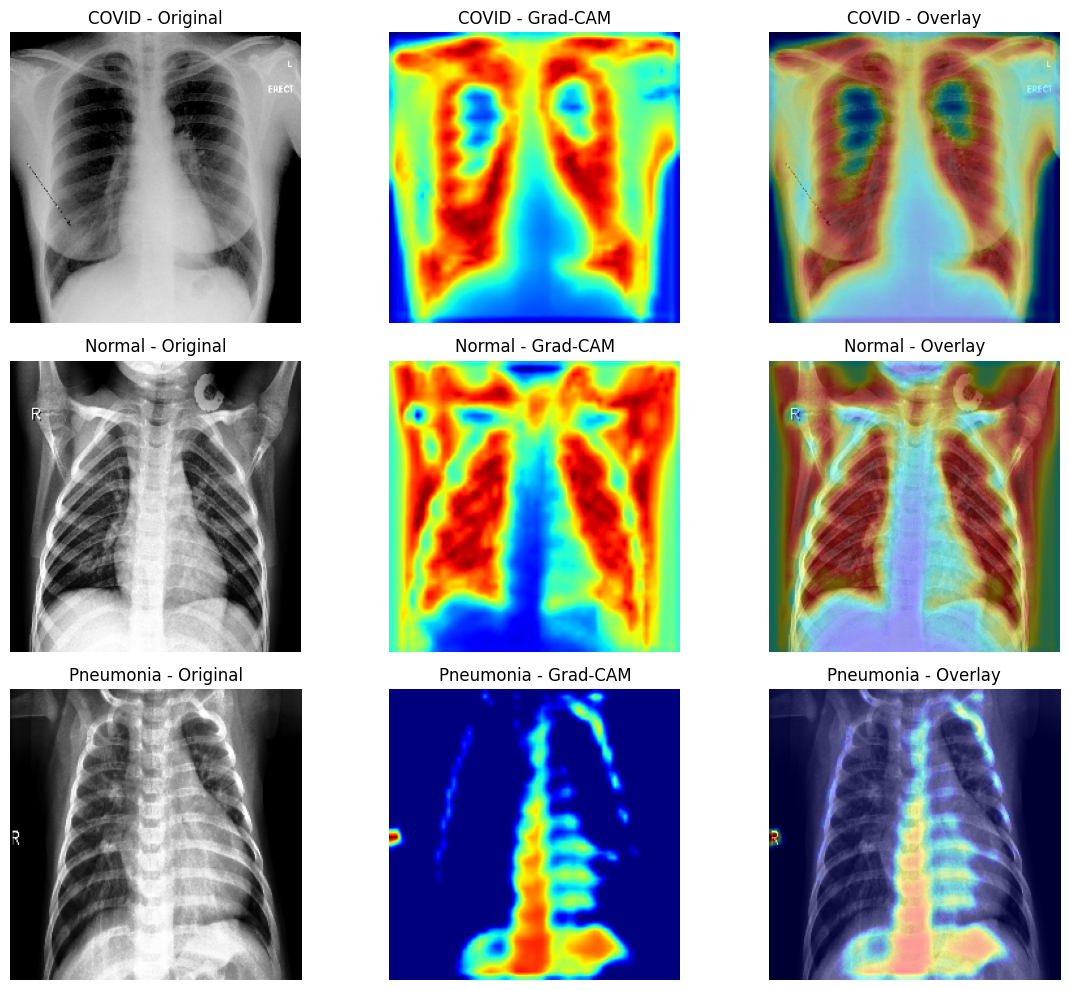

In [44]:
# ================================
# 1. IMPORTS
# ================================
import torch
import torch.nn as nn
import cv2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# ================================
# 2. DEVICE
# ================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ================================
# 3. CNN MODEL (MUST MATCH TRAINING)
# ================================
class SimpleCNN(nn.Module):
    def __init__(self, num_classes):
        super(SimpleCNN, self).__init__()

        self.conv1 = nn.Conv2d(3, 32, 3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.conv3 = nn.Conv2d(64, 128, 3, padding=1)

        self.pool = nn.MaxPool2d(2, 2)

        self.fc1 = nn.Linear(128 * 28 * 28, 256)
        self.fc2 = nn.Linear(256, num_classes)

    def forward(self, x):
        x = self.pool(torch.relu(self.conv1(x)))
        x = self.pool(torch.relu(self.conv2(x)))
        x = self.pool(torch.relu(self.conv3(x)))

        x = x.view(x.size(0), -1)

        x = torch.relu(self.fc1(x))
        x = self.fc2(x)

        return x

# ================================
# 4. LOAD MODEL
# ================================
NUM_CLASSES = 3

model = SimpleCNN(NUM_CLASSES)
model.load_state_dict(torch.load("artifacts/cnn_model.pth", map_location=device))

model = model.to(device)
model.eval()

# ================================
# 5. LOAD DATA
# ================================
df = pd.read_csv("artifacts/data_split.csv")

test_df = df[df["split"] == "test"]

test_paths = test_df["image_path"].tolist()
test_labels = test_df["label"].tolist()

# ================================
# 6. IMAGE LOADER
# ================================
def load_image(path):
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
    img = cv2.resize(img, (224, 224))

    img = img / 255.0

    img = np.transpose(img, (2, 0, 1))
    img = torch.tensor(img, dtype=torch.float).unsqueeze(0)

    return img

# ================================
# 7. GRAD-CAM CLASS
# ================================
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer

        self.gradients = None
        self.activations = None

        self.target_layer.register_forward_hook(self.save_activation)
        self.target_layer.register_backward_hook(self.save_gradient)

    def save_activation(self, module, input, output):
        self.activations = output

    def save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0]

    def generate(self, input_tensor, class_idx):
        self.model.zero_grad()

        output = self.model(input_tensor)
        loss = output[:, class_idx]
        loss.backward()

        gradients = self.gradients
        activations = self.activations

        weights = torch.mean(gradients, dim=(2, 3), keepdim=True)

        cam = torch.sum(weights * activations, dim=1).squeeze()
        cam = torch.relu(cam)

        cam = cam.detach().cpu().numpy()
        cam = cv2.resize(cam, (224, 224))

        cam = cam - cam.min()
        cam = cam / cam.max()

        return cam

# ================================
# 8. INIT GRAD-CAM
# ================================
target_layer = model.conv3
gradcam = GradCAM(model, target_layer)

# ================================
# 9. SELECT ONE IMAGE PER CLASS
# ================================
covid_idx = [i for i, l in enumerate(test_labels) if l == 0][0]
normal_idx = [i for i, l in enumerate(test_labels) if l == 1][0]
pneumonia_idx = [i for i, l in enumerate(test_labels) if l == 2][0]

covid_path = test_paths[covid_idx]
normal_path = test_paths[normal_idx]
pneumonia_path = test_paths[pneumonia_idx]

# ================================
# 10. FUNCTION TO GENERATE OUTPUT
# ================================
def get_gradcam(image_path):
    input_tensor = load_image(image_path).to(device)

    output = model(input_tensor)
    pred_class = torch.argmax(output).item()

    cam = gradcam.generate(input_tensor, pred_class)

    original = cv2.imread(image_path)
    original = cv2.resize(original, (224, 224))

    heatmap = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)
    overlay = cv2.addWeighted(original, 0.6, heatmap, 0.4, 0)

    return original, cam, overlay

# ================================
# 11. GENERATE FOR ALL CLASSES
# ================================
covid_orig, covid_cam, covid_overlay = get_gradcam(covid_path)
normal_orig, normal_cam, normal_overlay = get_gradcam(normal_path)
pneu_orig, pneu_cam, pneu_overlay = get_gradcam(pneumonia_path)

# ================================
# 12. VISUALIZATION
# ================================
plt.figure(figsize=(12,10))

# COVID
plt.subplot(3,3,1)
plt.title("COVID - Original")
plt.imshow(cv2.cvtColor(covid_orig, cv2.COLOR_BGR2RGB))
plt.axis("off")

plt.subplot(3,3,2)
plt.title("COVID - Grad-CAM")
plt.imshow(covid_cam, cmap='jet')
plt.axis("off")

plt.subplot(3,3,3)
plt.title("COVID - Overlay")
plt.imshow(cv2.cvtColor(covid_overlay, cv2.COLOR_BGR2RGB))
plt.axis("off")

# NORMAL
plt.subplot(3,3,4)
plt.title("Normal - Original")
plt.imshow(cv2.cvtColor(normal_orig, cv2.COLOR_BGR2RGB))
plt.axis("off")

plt.subplot(3,3,5)
plt.title("Normal - Grad-CAM")
plt.imshow(normal_cam, cmap='jet')
plt.axis("off")

plt.subplot(3,3,6)
plt.title("Normal - Overlay")
plt.imshow(cv2.cvtColor(normal_overlay, cv2.COLOR_BGR2RGB))
plt.axis("off")

# PNEUMONIA
plt.subplot(3,3,7)
plt.title("Pneumonia - Original")
plt.imshow(cv2.cvtColor(pneu_orig, cv2.COLOR_BGR2RGB))
plt.axis("off")

plt.subplot(3,3,8)
plt.title("Pneumonia - Grad-CAM")
plt.imshow(pneu_cam, cmap='jet')
plt.axis("off")

plt.subplot(3,3,9)
plt.title("Pneumonia - Overlay")
plt.imshow(cv2.cvtColor(pneu_overlay, cv2.COLOR_BGR2RGB))
plt.axis("off")

plt.tight_layout()
plt.show()